# 01 Preprocessing & ANOVA

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import pytensor.tensor as pt
import arviz as az

from rsa_models import (
    UTTERANCES, STATES, RELATIONS, N_utt, N_sta, N_rel,
    L0, state_vals, U_epi, U_soc_base,
    build_rsa_c, build_rsa_f,
    flat_speaker_logit, load_speaker_counts, load_speaker_logit_avg,
    flat_listener_logit, load_listener_counts, load_listener_logit_avg,
    save_trace, load_trace,
)

print('imports OK')

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


imports OK


In [17]:
# ── 파싱 결과 확인용 CSV 생성 (수동 수정 후 피팅에 사용) ────────────────────
# 실행 후 results/to_review/ 폴더의 CSV를 열어서
# 'parsed' 컬럼을 직접 수정 (listener: 1-5, speaker: 형용사)
# 수정 완료 후 피팅 셀 실행
import re, csv, glob
import pandas as pd
from pathlib import Path
from collections import Counter

def parse_state(text):
    text = str(text)
    text = re.sub(r'\bvon\s+[1-5]\b', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\bbis\s+[1-5]\b', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\bbetween\s+[1-5]\s+and\s+[1-5]\b', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\b5\s+Herzen\b', '', text, flags=re.IGNORECASE)
    text = re.sub(r'[1-5]\s*[-\u2013]\s*[1-5]', '', text)
    text = re.sub(r'[1-5]\s+(bis|to|und|oder)\s+[1-5]', '', text, flags=re.IGNORECASE)
    text = re.sub(r'[1-5](\s*,\s*[1-5]){2,}(\s*(oder|und|or)\s*[1-5])?', '', text, flags=re.IGNORECASE)
    text = re.sub(r'[1-5](\s*\|\s*[1-5]){2,}', '', text)
    digits = re.findall(r'(?<!\d)[1-5](?!\d)', text)
    if not digits: return ''
    counts = Counter(digits)
    top, top_n = counts.most_common(1)[0]
    if len(counts) == 1: return str(top)
    second_n = counts.most_common(2)[1][1]
    if top_n > 1 and second_n == 1: return str(top)
    return ''

def parse_adj(text):
    adjs = ['großartig', 'gut', 'okay', 'schlecht', 'schrecklich']
    t = str(text).strip().lower()
    for a in adjs:
        if t.startswith(a): return a
    for a in adjs:
        if a in t: return a
    return ''

Path('results/to_review').mkdir(exist_ok=True)
LLM_TAGS = ['qwen3-8b_zero', 'llama3-8b_zero']

for llm in LLM_TAGS:
    for role, mode, parser in [
        ('listener', 'choice', parse_state),
        ('speaker',  'choice', parse_adj),
    ]:
        files = glob.glob(f'results/csv/{role}_{mode}_{llm}.csv')
        if not files: continue

        df = pd.read_csv(files[0])
        df['parsed'] = df['response_text'].apply(parser)

        out = Path(f'results/to_review/{role}_{mode}_{llm}.csv')
        # 파싱 실패('') 행을 맨 위로 정렬 → 수정하기 쉽게
        df_fail = df[df['parsed'] == '']
        df_ok   = df[df['parsed'] != '']
        df_sorted = pd.concat([df_fail, df_ok], ignore_index=True)
        df_sorted.to_csv(out, index=False, encoding='utf-8')

        n_fail = (df['parsed'] == '').sum()
        print(f'{out}  →  자동파싱 성공: {len(df)-n_fail}/{len(df)}, 실패(맨 위): {n_fail}')

print('\n✓ 완료. results/to_review/ 폴더의 CSV를 열어 parsed 컬럼 수정 후 저장하세요.')


results/to_review/listener_choice_qwen3-8b_zero.csv  →  자동파싱 성공: 5000/5000, 실패(맨 위): 0
results/to_review/speaker_choice_qwen3-8b_zero.csv  →  자동파싱 성공: 5000/5000, 실패(맨 위): 0
results/to_review/listener_choice_llama3-8b_zero.csv  →  자동파싱 성공: 4906/5000, 실패(맨 위): 94
results/to_review/speaker_choice_llama3-8b_zero.csv  →  자동파싱 성공: 5000/5000, 실패(맨 위): 0

✓ 완료. results/to_review/ 폴더의 CSV를 열어 parsed 컬럼 수정 후 저장하세요.


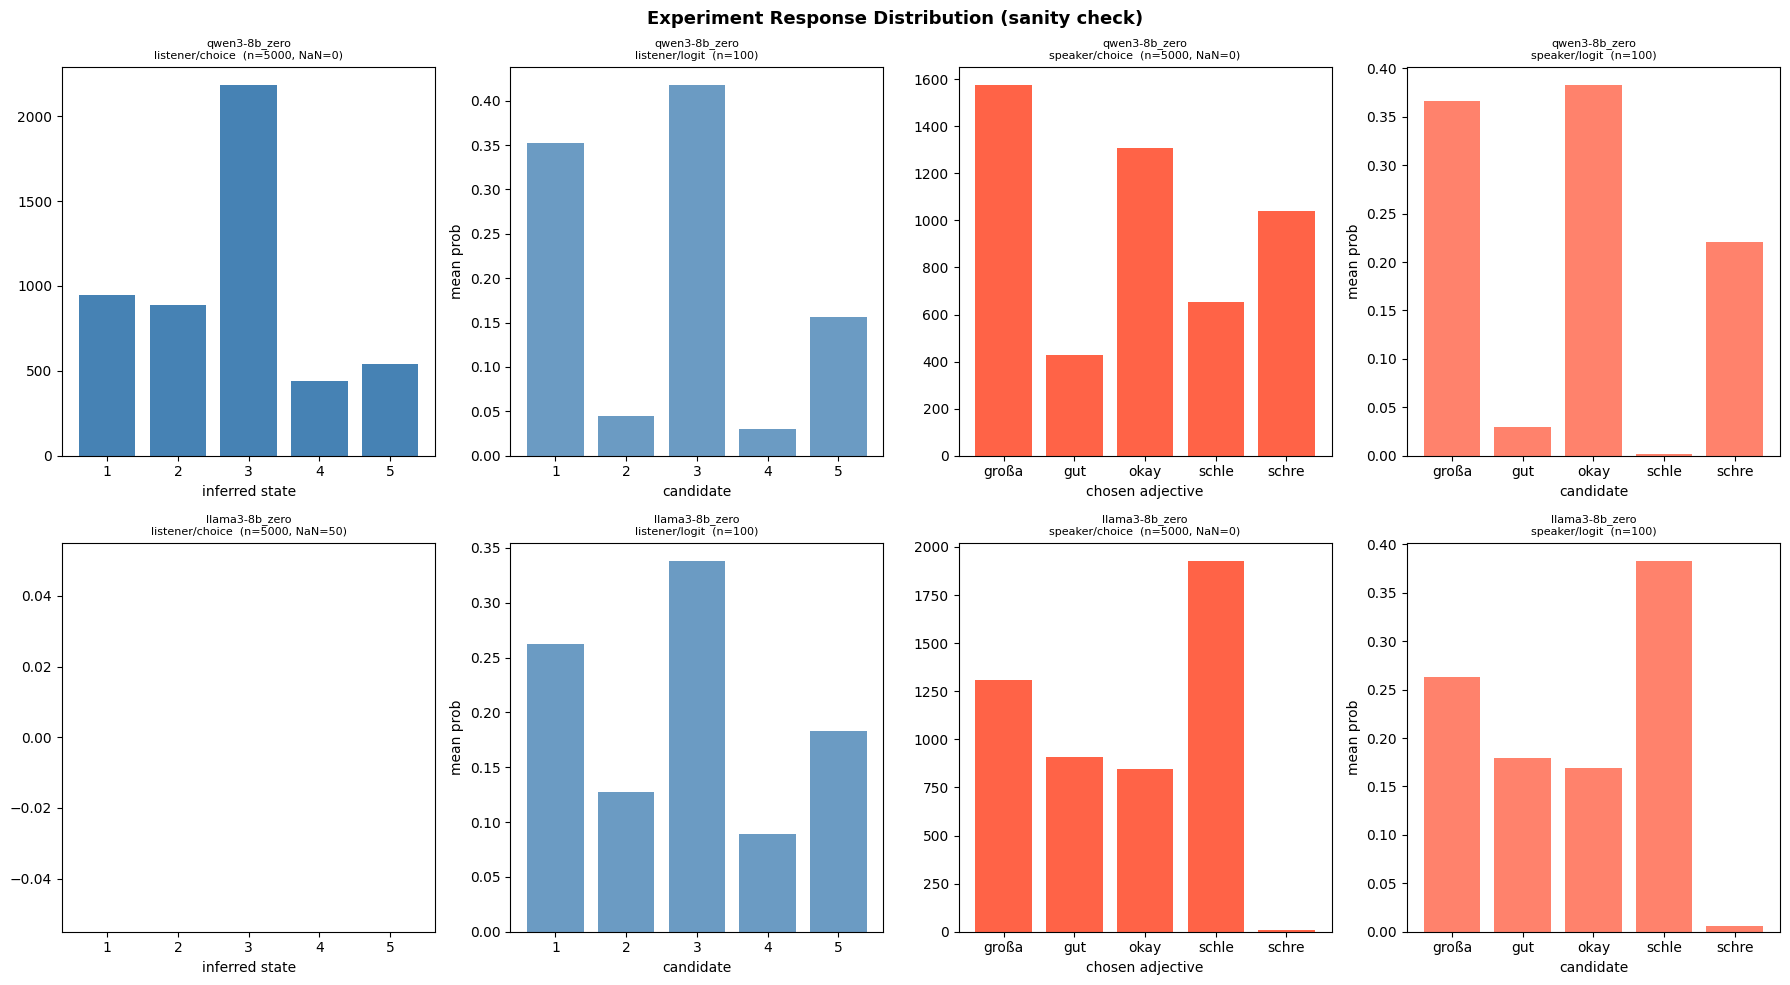

저장 → results/sanity_check.png


In [21]:
# ── 실험 결과 분포 확인 (sanity check) ──────────────────────────────────────
import glob, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ADJ_ORDER  = ['großartig', 'gut', 'okay', 'schlecht', 'schrecklich']
LLM_TAGS   = ['qwen3-8b_zero', 'llama3-8b_zero']

fig, axes = plt.subplots(len(LLM_TAGS), 4, figsize=(18, 5 * len(LLM_TAGS)))
if len(LLM_TAGS) == 1: axes = axes[None, :]

for row_i, llm in enumerate(LLM_TAGS):
    col_i = 0
    for role in ['listener', 'speaker']:
        for mode in ['choice', 'logit']:
            ax = axes[row_i, col_i]

            if mode == 'choice':
                p = Path(f'results/to_review/{role}_choice_{llm}.csv')
                if not p.exists(): p = Path(f'results/csv/{role}_choice_{llm}.csv')
                if not p.exists():
                    ax.set_title(f'{role}/{mode}\n[파일 없음]', fontsize=9)
                    ax.axis('off'); col_i += 1; continue
                df = pd.read_csv(p)
                vals = df['parsed'].replace('', pd.NA).dropna()
                total = len(df); nan_n = df['parsed'].replace('', pd.NA).isna().sum()
                if role == 'listener':
                    counts = [sum(vals.astype(str) == str(s)) for s in [1,2,3,4,5]]
                    ax.bar(['1','2','3','4','5'], counts, color='steelblue')
                    ax.set_xlabel('inferred state')
                else:
                    counts = [sum(vals == a) for a in ADJ_ORDER]
                    ax.bar([a[:5] for a in ADJ_ORDER], counts, color='tomato')
                    ax.set_xlabel('chosen adjective')
                ax.set_title(f'{llm}\n{role}/{mode}  (n={total}, NaN={nan_n})', fontsize=8)

            else:  # logit
                p = Path(f'results/csv/{role}_logit_{llm}.csv')
                if not p.exists():
                    ax.set_title(f'{role}/{mode}\n[파일 없음]', fontsize=9)
                    ax.axis('off'); col_i += 1; continue
                df = pd.read_csv(p); total = len(df)
                if role == 'listener':
                    cols   = [f'prob_{s}' for s in [1,2,3,4,5]]
                    labels = ['1','2','3','4','5']; color = 'steelblue'
                else:
                    cols   = [f'prob_{a}' for a in ADJ_ORDER]
                    labels = [a[:5] for a in ADJ_ORDER]; color = 'tomato'
                avgs = [df[c].mean() if c in df.columns else 0 for c in cols]
                ax.bar(labels, avgs, color=color, alpha=0.8)
                ax.set_xlabel('candidate'); ax.set_ylabel('mean prob')
                ax.set_title(f'{llm}\n{role}/{mode}  (n={total})', fontsize=8)

            col_i += 1

plt.suptitle('Experiment Response Distribution (sanity check)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/sanity_check.png', dpi=120, bbox_inches='tight')
plt.show()
print('저장 → results/sanity_check.png')


In [14]:
# ── 파싱 실패 항목 → CSV 저장 ────────────────────────────────────────────────
# to_review CSV의 parsed 컬럼이 비어있는 행 = 수동 수정 필요
import pandas as pd
from pathlib import Path

LLM_TAGS = ['qwen3-8b_zero', 'llama3-8b_zero']
Path('results/parse_fails').mkdir(exist_ok=True)

for llm in LLM_TAGS:
    for role in ['listener', 'speaker']:
        p = Path(f'results/to_review/{role}_choice_{llm}.csv')
        if not p.exists():
            print(f'[없음] {p}'); continue
        df = pd.read_csv(p)
        fails = df[df['parsed'].replace('', pd.NA).isna()]
        out = Path(f'results/parse_fails/{role}_choice_{llm}_fails.csv')
        fails.to_csv(out, index=False, encoding='utf-8')
        print(f'{out}  ({len(fails)}/{len(df)} fails, {100*len(fails)/len(df):.1f}%)')


results/parse_fails/listener_choice_qwen3-8b_zero_fails.csv  (0/3000 fails, 0.0%)
results/parse_fails/speaker_choice_qwen3-8b_zero_fails.csv  (0/3000 fails, 0.0%)
results/parse_fails/listener_choice_llama3-8b_zero_fails.csv  (14/3000 fails, 0.5%)
results/parse_fails/speaker_choice_llama3-8b_zero_fails.csv  (0/3000 fails, 0.0%)


Anova Test

In [23]:
# ── Statistical Tests: LLM Data ──────────────────────────────────────────────
# Listener : Two-way ANOVA  (inferred state 1-5, ordinal treated as interval)
# Speaker  : Chi-square test (chosen adjective is nominal — ANOVA inappropriate)
import pandas as pd
import numpy as np
import pingouin as pg
from scipy.stats import chi2_contingency
from pathlib import Path
from statsmodels.stats.multicomp import pairwise_tukeyhsd

ADJ_ORDER = ['großartig', 'gut', 'okay', 'schlecht', 'schrecklich']
REL_MAP = {
    'Enge Freundin':      'Close friend',
    'Entfernte Kollegin': 'Distant colleague',
    'Lockere Chefin':     'Easy-going boss',
    'Gefürchtete Chefin': 'Dreaded boss',
}

def load_choice(role, llm):
    p = Path(f'results/to_review/{role}_choice_{llm}.csv')
    if not p.exists(): p = Path(f'results/csv/{role}_choice_{llm}.csv')
    if not p.exists(): return None
    df = pd.read_csv(p)
    df['_val'] = df['parsed'].replace('', pd.NA) if 'parsed' in df.columns else pd.NA
    df = df.dropna(subset=['_val'])
    df['relationship'] = df['relationship'].map(REL_MAP).fillna(df['relationship'])
    return df

def run_anova_block(df, dv, between, label):
    df = df.dropna(subset=[dv] + between)
    print(f"\n{'='*60}\n  {label}  (n={len(df)})\n  DV: {dv}   Factors: {between}\n{'='*60}")
    aov = pg.anova(data=df, dv=dv, between=between, detailed=True)
    print(aov[['Source','SS','DF','MS','F','p-unc','np2']].to_string(index=False))
    for factor in between:
        print(f"\n  Post-hoc Tukey HSD: {factor}")
        print(pairwise_tukeyhsd(df[dv], df[factor], alpha=0.05).summary())

def run_chisq_block(df, label):
    """Chi-square test of independence: chosen adjective ~ relationship and ~ state"""
    print(f"\n{'='*60}\n  {label}  (n={len(df)})\n{'='*60}")
    df = df.copy()
    df['utterance'] = df['_val'].str.strip()

    for factor_col in ['relationship', 'state']:
        if factor_col not in df.columns:
            continue
        ct = pd.crosstab(df[factor_col], df['utterance'])
        for adj in ADJ_ORDER:
            if adj not in ct.columns: ct[adj] = 0
        ct = ct[ADJ_ORDER]
        chi2, p, dof, _ = chi2_contingency(ct)
        n = ct.values.sum()
        cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
        print(f"\n  Factor: {factor_col}")
        print(f"    χ²({dof}) = {chi2:.3f},  p = {p:.4f},  Cramér's V = {cramers_v:.3f}  (n={n})")
        print(f"\n  Contingency table (counts):")
        print(ct.to_string())

# ── Human reference (Listener ANOVA — Lumer 2023 Table C.1) ─────────────────
print("#"*60)
print("  HUMAN LISTENER — Lumer 2023 (Table C.1)")
print("#"*60)
human = pd.DataFrame({
    'Source': ['relationship', 'target_word', 'relationship × target_word'],
    'SS':   [62.687, 2437.730, 48.280], 'DF': [3, 4, 12],
    'MS':   [20.896,  609.432,  4.023],
    'F':    [48.582, 1416.911,  9.354],
    'p':    ['< .001', '< .001', '< .001'],
    'eta2': [0.019, 0.747, 0.015],
})
print(human.to_string(index=False))

LLM_TAGS = ['qwen3-8b_zero', 'llama3-8b_zero']

for llm in LLM_TAGS:
    print(f"\n\n{'#'*60}\n  LLM: {llm}\n{'#'*60}")

    # ── Listener: Two-way ANOVA ───────────────────────────────────────────
    df_li = load_choice('listener', llm)
    if df_li is not None:
        df_li['inferred_state'] = pd.to_numeric(df_li['_val'], errors='coerce')
        df_li['target_word']    = df_li['adjective'].str.strip()
        run_anova_block(df_li, dv='inferred_state',
                        between=['relationship', 'target_word'],
                        label=f'LISTENER — {llm}')

    # ── Speaker: Chi-square ───────────────────────────────────────────────
    df_sp = load_choice('speaker', llm)
    if df_sp is not None:
        run_chisq_block(df_sp, label=f'SPEAKER — {llm}')

# ── Bayesian t-test: Qwen vs LLaMA (Listener only) ──────────────────────────
print(f"\n\n{'#'*60}\n  BAYESIAN t-TEST: Qwen3-8B vs LLaMA3-8B  (Listener inferred state)\n{'#'*60}")

dfs = {}
for llm in LLM_TAGS:
    df = load_choice('listener', llm)
    if df is not None:
        df['inferred_state'] = pd.to_numeric(df['_val'], errors='coerce')
        dfs[llm] = df['inferred_state'].dropna().values

if len(dfs) == 2:
    q, l = dfs[LLM_TAGS[0]], dfs[LLM_TAGS[1]]
    res = pg.ttest(q, l, paired=False, alternative='two-sided')
    bf  = float(res['BF10'].values[0])
    evidence = ('extreme H1' if bf>100 else 'very strong H1' if bf>30 else
                'strong H1' if bf>10 else 'moderate H1' if bf>3 else
                'anecdotal H1' if bf>1 else 'anecdotal H0' if bf>1/3 else 'moderate H0')
    print(f"\n  {LLM_TAGS[0]} mean={q.mean():.3f}  n={len(q)}")
    print(f"  {LLM_TAGS[1]} mean={l.mean():.3f}  n={len(l)}")
    print(f"  t={float(res['T'].values[0]):.3f}  p={float(res['p-val'].values[0]):.4f}  d={float(res['cohen-d'].values[0]):.3f}")
    print(f"  BF10={bf:.2f}  → {evidence}")

# ── Speaker: Chi-square Qwen vs LLaMA ───────────────────────────────────────
print(f"\n\n{'#'*60}\n  CHI-SQUARE: Qwen3-8B vs LLaMA3-8B  (Speaker chosen adjective)\n{'#'*60}")

sp_parts = []
for llm, short in zip(LLM_TAGS, ['Qwen3', 'LLaMA3']):
    df = load_choice('speaker', llm)
    if df is not None:
        df['utterance'] = df['_val'].str.strip()
        df['llm'] = short
        sp_parts.append(df)

if len(sp_parts) == 2:
    combined = pd.concat(sp_parts)
    ct = pd.crosstab(combined['llm'], combined['utterance'])
    for adj in ADJ_ORDER:
        if adj not in ct.columns: ct[adj] = 0
    ct = ct[ADJ_ORDER]
    chi2, p, dof, _ = chi2_contingency(ct)
    n = ct.values.sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    print(f"\n  Qwen3 vs LLaMA3 — chosen adjective distribution")
    print(f"  χ²({dof}) = {chi2:.3f},  p = {p:.4f},  Cramér's V = {cramers_v:.3f}  (n={n})")
    print(f"\n  Contingency table (counts):")
    print(ct.to_string())


############################################################
  HUMAN LISTENER — Lumer 2023 (Table C.1)
############################################################
                    Source       SS  DF      MS        F      p  eta2
              relationship   62.687   3  20.896   48.582 < .001 0.019
               target_word 2437.730   4 609.432 1416.911 < .001 0.747
relationship × target_word   48.280  12   4.023    9.354 < .001 0.015


############################################################
  LLM: qwen3-8b_zero
############################################################

  LISTENER — qwen3-8b_zero  (n=5000)
  DV: inferred_state   Factors: ['relationship', 'target_word']
                    Source        SS   DF          MS           F        p-unc      np2
              relationship   10.3222    3    3.440733   21.537343 7.427549e-14 0.012808
               target_word 6123.8048    4 1530.951200 9583.021584 0.000000e+00 0.885021
relationship * target_word   38.2688   12    